In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from sklearn.model_selection import train_test_split
from split.create_split import create_split
import torch

from models.random_forest import RandomForestPredictor

from main_scorer import plot_results, plot_umap_embedding
from models.oracle import build_oracle_df, oracle_lookup
from models.lstm_goaldirected import LSTMGoalDirected
from models import mlp_oracle


SEED = 42

### Train LSTM with Reniforcement Learning - TFBind8

In [2]:
# Load dataset: TFBIND 8 - SIX6 REF R1
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')

# Add a column encoded sequence instead of the cols 0-7
df['encoded_sequence'] = df.apply(lambda row: [row[str(i)] for i in range(8)], axis=1)


df['split'] = ['None'] * len(df)

df = create_split(df, k_seeds=50, n_training_seeds=20, random_state=42)

train_df = df[df['split'] == 'train']

x = train_df.iloc[:, :-6].values
print('Shape of x:', x.shape)
print('First row of x:', x[0])
y = train_df['binding_scores'].values

# One-hot encode and reshape to 3D for LSTM (samples, timesteps, features)
x_one_hot = np.array([tf.one_hot(seq, depth=4).numpy() for seq in x])
print('One-hot encoded shape (3D):', x_one_hot.shape)

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)

print('Training samples: ', X_train.shape[0])
print('Validation samples: ', X_val.shape[0])
print('Input shape (timesteps, features):', X_train.shape[1:])

Shape of x: (8670, 8)
First row of x: [0 0 0 0 0 0 2 1]


I0000 00:00:1772010706.976300    5942 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2604 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


One-hot encoded shape (3D): (8670, 8, 4)
Training samples:  7803
Validation samples:  867
Input shape (timesteps, features): (8,)


In [3]:
# check sizes of testsplits
df['split'].value_counts()

split
test_c    38796
test_a    10614
train      8670
test_b     7712
Name: count, dtype: int64

In [42]:

rf = RandomForestPredictor()
rf.train(X_train, y_train)
rf.evaluate(X_val, y_val)

Training Random Forest model...
Training completed.
R2 Score: 0.15918134423136332
MSE: 0.004913540435817986
Spearman Correlation: 0.3804144933321289


{'r2': 0.15918134423136332,
 'mse': 0.004913540435817986,
 'spearman_correlation': np.float64(0.3804144933321289)}

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset

X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [2]:
def train_goal_directed_model(model, loader, epochs=20, lr= 0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):
        epoch_loss = 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()

            input = batch_x[:, :-1]
            target_part = batch_x[:, 1:]
            #print('Input shape:', input.shape)
            #print('Target part shape:', batch_y.shape)
            logits, _ = model(input, batch_y)
            loss = criterion(logits.reshape(-1, model.vocab_size), target_part.reshape(-1))

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        if epoch % 5 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(loader)}')

#### Iterative Feedback Loop with retraining

In [ ]:
def rl_loop(model, scorer, oracle, num_iterations=6, batch_size = 128, X_train=None, y_train=None, GB1=False):
    values = {'mutation': [], 'predicted_score': [], 'real_score': []}
    for i in range(num_iterations):
        print(f'-------- Iteration {i+1}/{num_iterations} --------')
        
        ### Propose new sequences
        new_sequences = []
        # Propose new sequences
        for _ in range(batch_size):
            seq = model.generate(goal_score=1.1, temp = 0.8)
            new_sequences.append(seq)

        new_sequences_np = np.array(new_sequences)
        
        ### Score new sequences by RF
        scores = []
        for seq in new_sequences_np:
            scores.append(scorer.predict(seq))

        scores = np.array(scores)

        ### Lookup oracle for real scores
        real_scores = []
        for seq in new_sequences_np:
            if GB1:
                seq_one_hot = tf.one_hot(seq, depth=20).numpy()
                real_score = oracle.inference(torch.tensor(seq_one_hot.flatten(), dtype=torch.float32)).item()
                
            else:
                real_score = oracle_lookup(oracle, seq)
            real_scores.append(real_score)

        real_scores_np = np.array(real_scores)

        ### Select top 20% sequences based on real scores
        threshold = np.percentile(real_scores, 80)
        top_sequences = new_sequences_np[real_scores_np >= threshold]
        top_scores = scores[real_scores_np >= threshold]
        top_real_scores = real_scores_np[real_scores_np >= threshold]


        print(f'Average score of proposed: {np.mean(scores):.4f}, Averagle real score: {np.mean(real_scores_np):.4f}, Average score of top 20%: {np.mean(top_scores):.4f}')

        # Append for plotting
        values['mutation'].extend(top_sequences) # Store the actual sequences for later analysis
        values['predicted_score'].extend(top_scores)
        values['real_score'].extend(top_real_scores)
        
        # Update LSTM model with top sequences
        x_train_tensor = torch.LongTensor(top_sequences)
        y_train_tensor = torch.FloatTensor(top_real_scores).view(-1, 1)

        dataloader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=16, shuffle=True)
        train_goal_directed_model(model, dataloader, epochs=20, lr=0.001)

        # Updatate RF model ### Retraining raus!!!!
        X_train = np.concatenate((X_train, new_sequences_np), axis=0)
        y_train = np.concatenate((y_train, real_scores_np), axis=0)
        rf.train(X_train, y_train)

    return values


Spearman Correlation: 0.5569


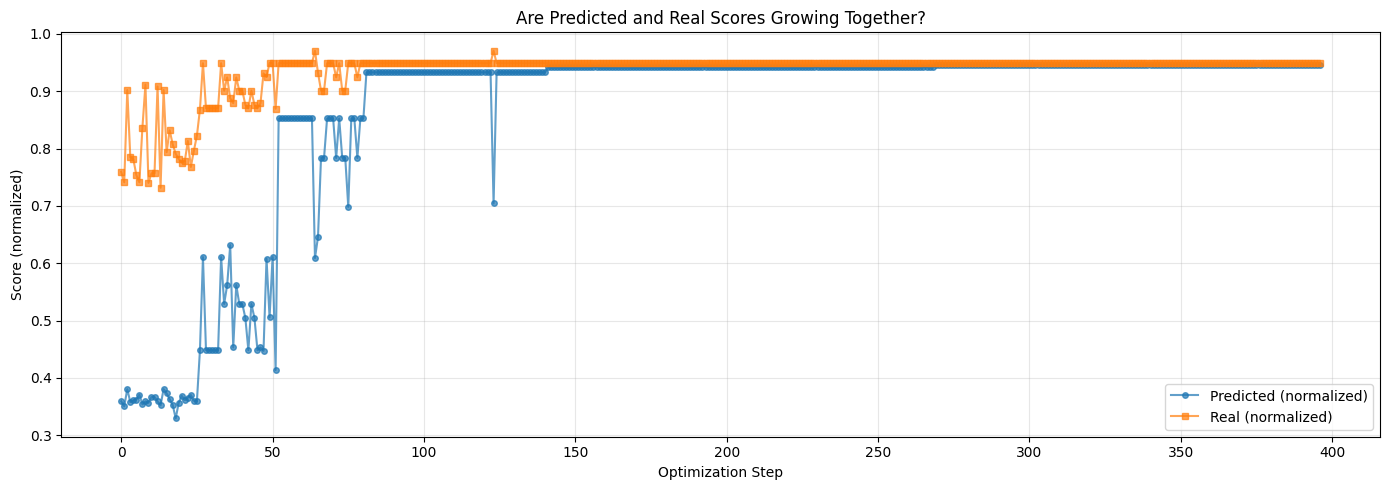

In [ ]:
model = LSTMGoalDirected(vocab_size=4, embedding_dim=16, seq_len=8, hidden_dim=64)
#First train the model on the original trianing data
train_goal_directed_model(model, train_loader, epochs=50, lr=0.001)

rf = RandomForestPredictor()
rf.train(X_train, y_train)
rf.evaluate(X_val, y_val)

oracle = build_oracle_df(df)

values = rl_loop(model, rf, oracle, num_iterations=6, batch_size=128, X_train=X_train, y_train=y_train)
values_df = pd.DataFrame(values)
values_df.head()
plot_results(values_df)

In [51]:
from models.oracle import oracle_lookup

def lookup_oracle_testset(values, oracle):
    """ Look up real scores in generated sequences. If not found, drop the row. """
    drop_cont = 0
    scores = []
    for seq in values['mutation']:
        score = oracle_lookup(oracle, seq)
        if score is not None and score > 0.0:
            scores.append(score)
        else:
            scores.append(np.nan)
            drop_cont += 1
    print(f'Number of sequences not found in oracle: {drop_cont}')
    values['real_score'] = scores
    return values


Number of sequences not found in oracle: 370
Spearman Correlation: 0.6568


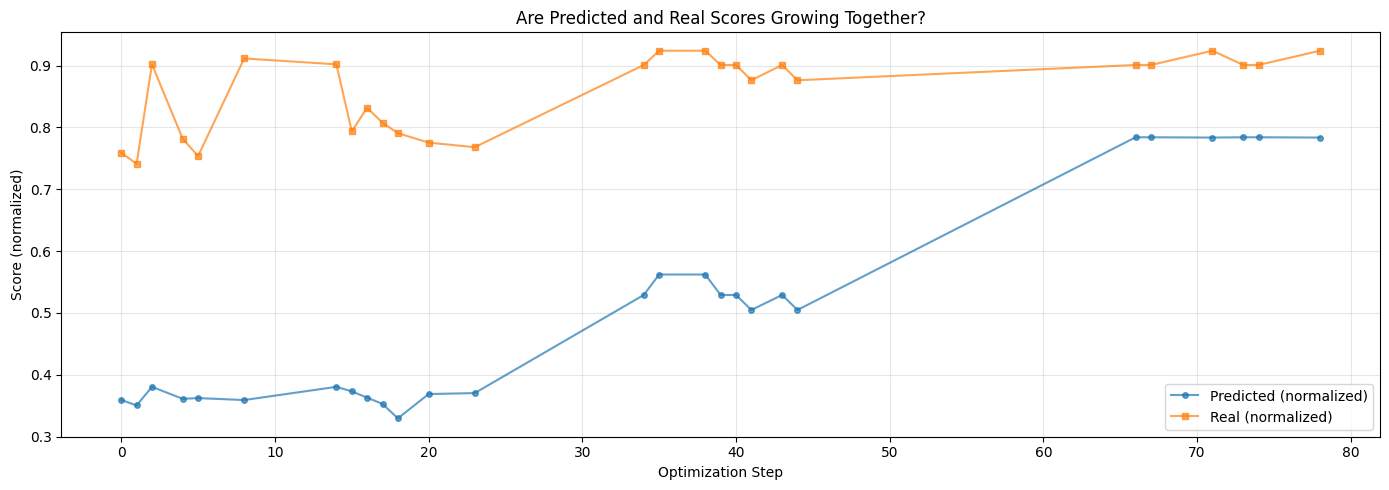

In [53]:
values_copy = values_df.copy()
values_copy.drop(columns=['real_score'], errors='ignore', inplace=True) # Drop real_score if it already exists to avoid confusion
test_a_oracle = build_oracle_df(df[df['split'] == 'test_a'])
test_a_df = lookup_oracle_testset(values_copy, test_a_oracle)
# drop rows with NaN real_score (sequences not found in oracle)
test_a_df = test_a_df.dropna(subset=['real_score'], inplace=False)
plot_results(test_a_df)

/tmp/ipykernel_5942/1776154835.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_a_df['mutation'] = test_a_df['mutation'].apply(
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


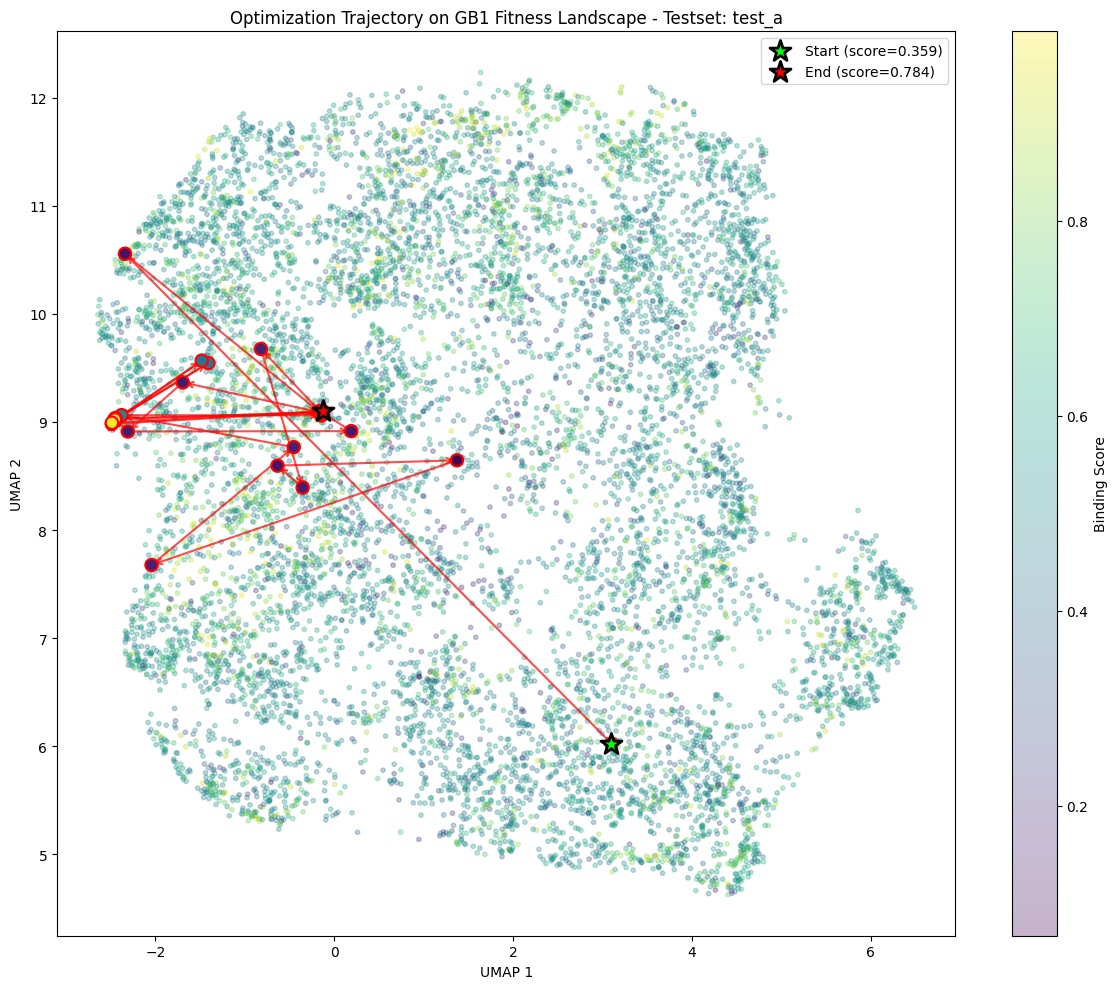

In [54]:
test_a_df['mutation'] = test_a_df['mutation'].apply(
    lambda seq: tf.one_hot(list(seq), depth=20).numpy().flatten()
)

plot_umap_embedding(df, 'test_a', test_a_df)

Number of sequences not found in oracle: 51
Spearman Correlation: 0.2721


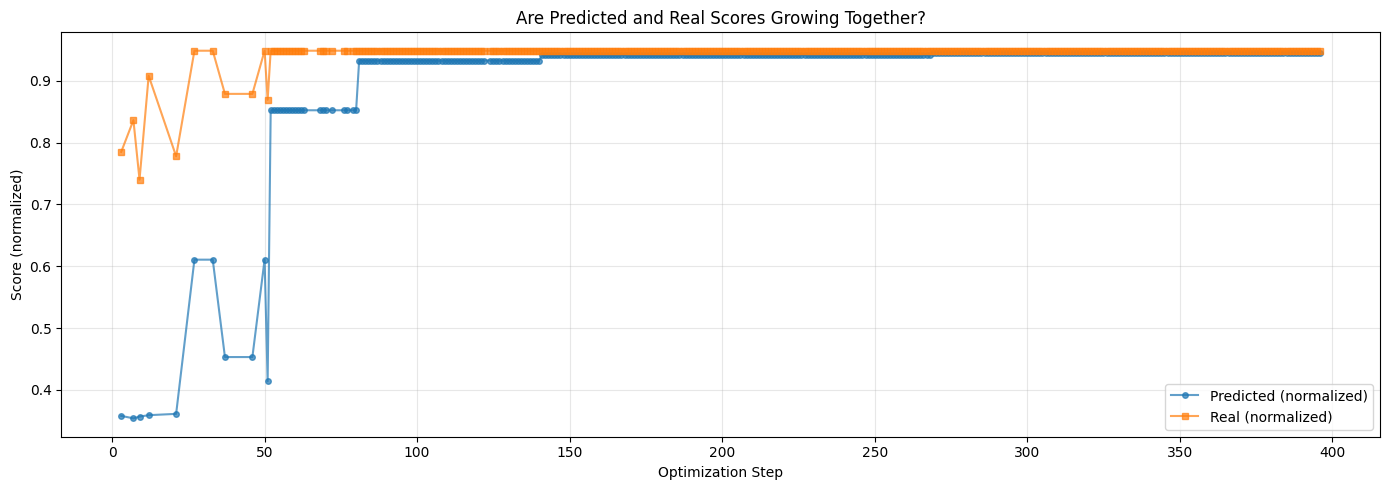

In [55]:
values_copy = values_df.copy()
values_copy.drop(columns=['real_score'], errors='ignore', inplace=True) # Drop real_score if it already exists to avoid confusion
test_b_oracle = build_oracle_df(df[df['split'] == 'test_b'])

test_b_df = lookup_oracle_testset(values_copy, test_b_oracle)
# drop rows with NaN real_score (sequences not found in oracle)
test_b_df = test_b_df.dropna(subset=['real_score'], inplace=False)
plot_results(test_b_df)

/tmp/ipykernel_5942/2789803479.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_b_df['mutation'] = test_b_df['mutation'].apply(
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


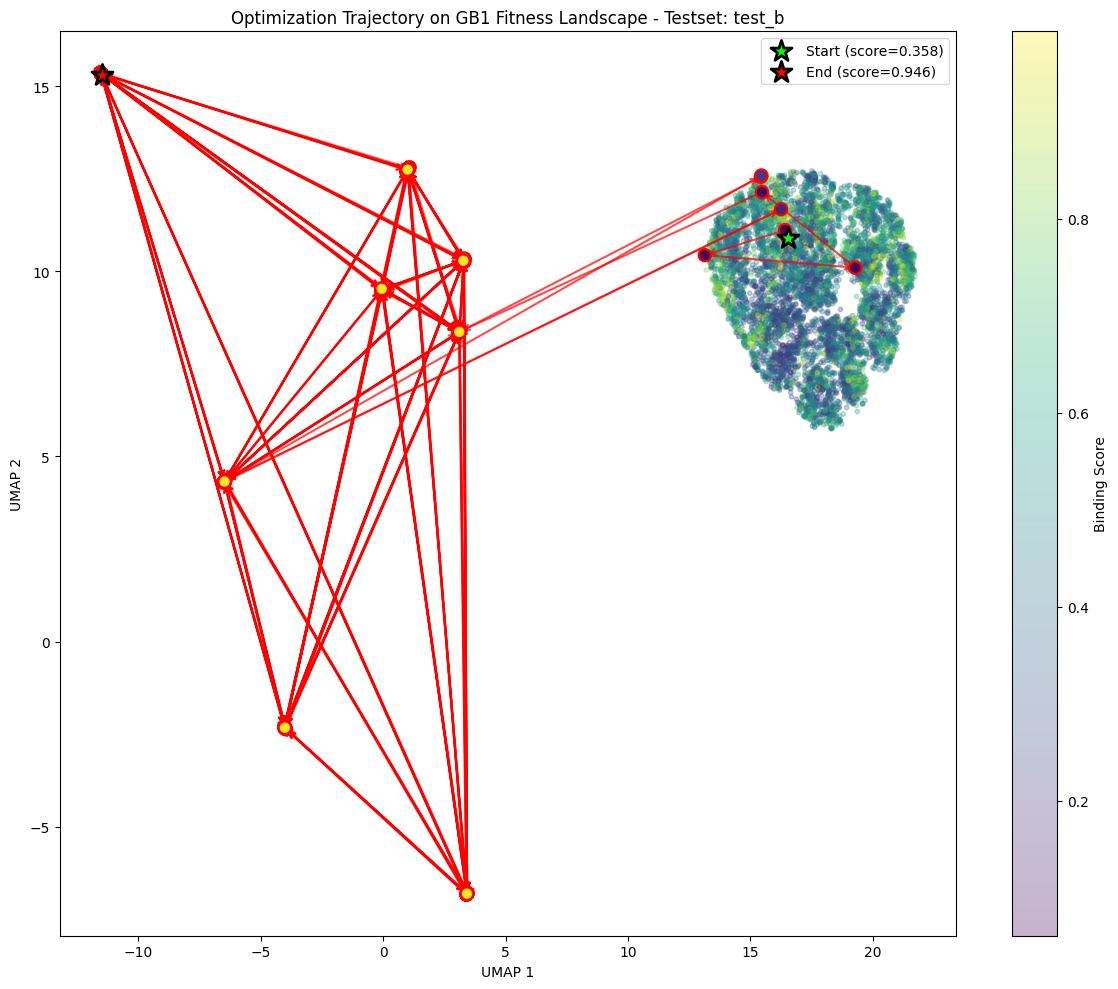

In [56]:
test_b_df['mutation'] = test_b_df['mutation'].apply(
    lambda seq: tf.one_hot(list(seq), depth=20).numpy().flatten()
)

plot_umap_embedding(df, 'test_b', test_b_df)

Number of sequences not found in oracle: 373
Spearman Correlation: 0.8794


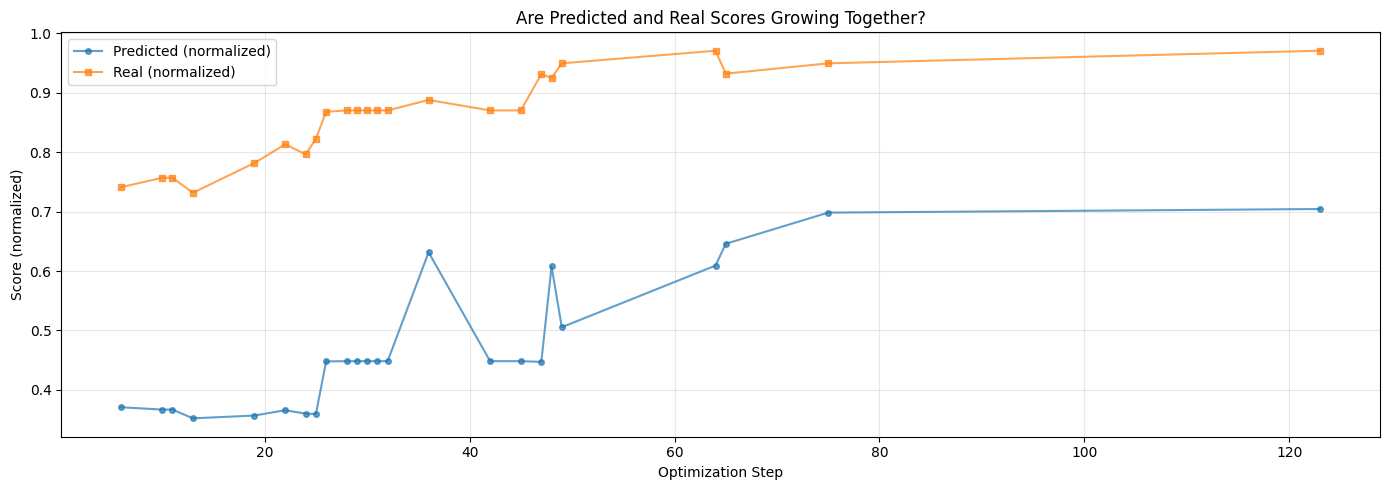

In [57]:
values_copy = values_df.copy()
values_copy.drop(columns=['real_score'], errors='ignore', inplace=True) # Drop real_score if it already exists to avoid confusion
test_c_oracle = build_oracle_df(df[df['split'] == 'test_c'])
test_c_df = lookup_oracle_testset(values_copy, test_c_oracle)
test_c_df = test_c_df.dropna(subset=['real_score'], inplace=False)
plot_results(test_c_df)

/tmp/ipykernel_5942/3429628584.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_c_df['mutation'] = test_c_df['mutation'].apply(
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


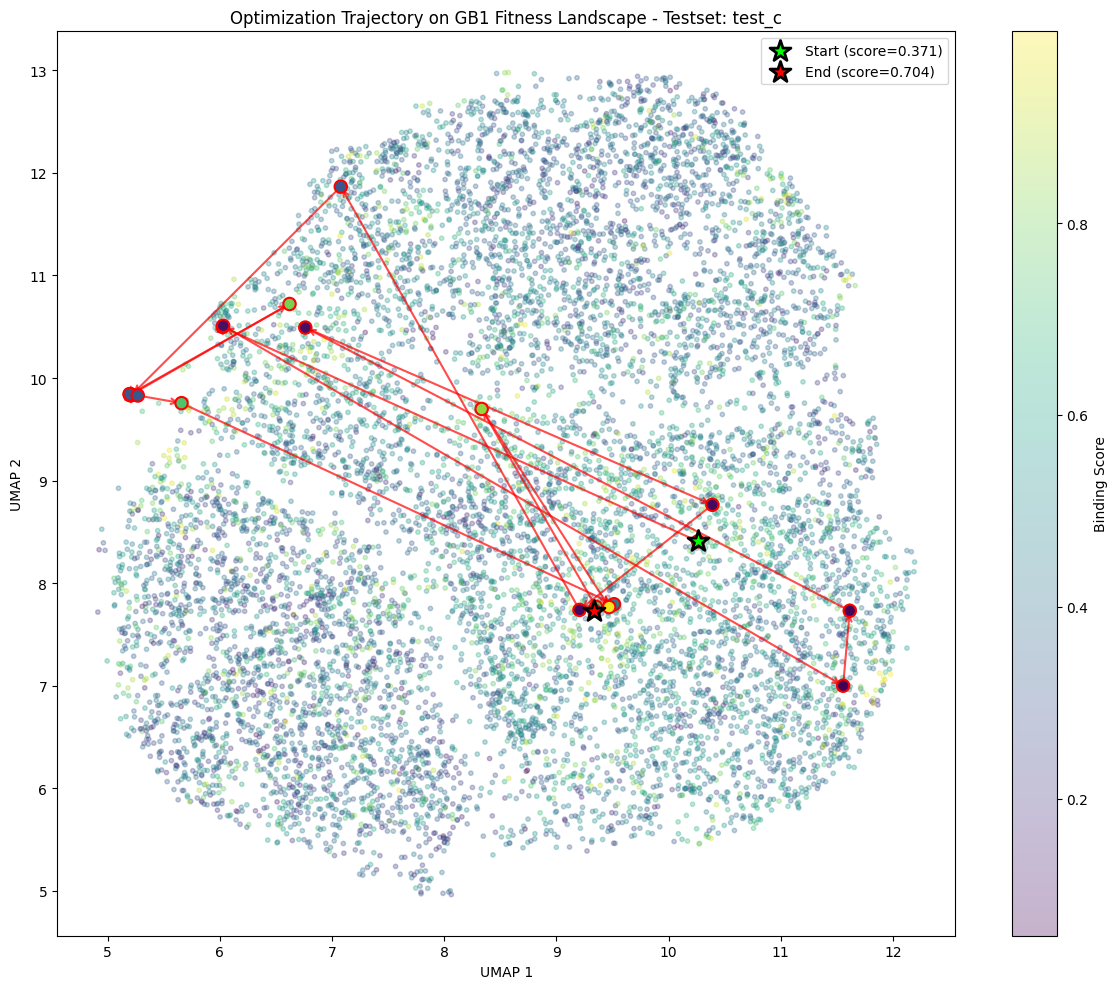

In [58]:
test_c_df['mutation'] = test_c_df['mutation'].apply(
    lambda seq: tf.one_hot(list(seq), depth=20).numpy().flatten()
)

plot_umap_embedding(df, 'test_c', test_c_df)

### GB-1 Dataset

In [4]:
# Load dataset: GB1

import ast
df = pd.read_csv('GB1_data/dataframe.csv')
df.head()
df['encoded_sequence'] = df['encoded_sequence'].apply(ast.literal_eval)

# Create train Data 
train_df = df[df['split'] == 'train']

# print stats about train split
print("Original train split stats:")
print(train_df['binding_scores'].describe())

# === EMPHASIZE EXTREMES: Oversample top and bottom 20% ===
def create_extreme_emphasized_data(df, extreme_percentile=20, oversample_factor=5):
    """Oversample the extreme fitness values (top and bottom percentiles)."""
    df = df.copy()
    
    low_threshold = np.percentile(df['binding_scores'], extreme_percentile)
    high_threshold = np.percentile(df['binding_scores'], 100 - extreme_percentile)
    
    # Split into low, middle, high
    df_low = df[df['binding_scores'] <= low_threshold]
    df_high = df[df['binding_scores'] >= high_threshold]
    df_middle = df[(df['binding_scores'] > low_threshold) & (df['binding_scores'] < high_threshold)]
    
    print(f"Low fitness (bottom {extreme_percentile}%): {len(df_low)} sequences, scores <= {low_threshold:.2f}")
    print(f"High fitness (top {extreme_percentile}%): {len(df_high)} sequences, scores >= {high_threshold:.2f}")
    print(f"Middle: {len(df_middle)} sequences")
    
    # Oversample extremes
    df_low_oversampled = df_low.sample(n=len(df_low) * oversample_factor, replace=True, random_state=SEED)
    df_high_oversampled = df_high.sample(n=len(df_high) * oversample_factor, replace=True, random_state=SEED)
    
    # Combine
    emphasized_df = pd.concat([df_low_oversampled, df_middle, df_high_oversampled], ignore_index=True)
    return emphasized_df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # Shuffle

# Create emphasized version
emphasized_train_df = create_extreme_emphasized_data(train_df, extreme_percentile=20, oversample_factor=3)

print("\nEmphasized training data stats:")
print(emphasized_train_df['binding_scores'].describe())
print(f"\nOriginal size: {len(train_df)}, Emphasized size: {len(emphasized_train_df)}")

# Use emphasized data for training
x = np.array(emphasized_train_df['encoded_sequence'].tolist())
y = emphasized_train_df['binding_scores'].values

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)
# One hot encoding
X_train_onehot = tf.one_hot(X_train, depth=20).numpy()
X_val_onehot = tf.one_hot(X_val, depth=20).numpy()

print(f"\nTraining set shape: {X_train_onehot.shape}")
print(f"Training labels range: [{y_train.min():.2f}, {y_train.max():.2f}]")


Original train split stats:
count    21218.000000
mean        -5.978772
std          1.641543
min        -10.896890
25%         -7.281526
50%         -6.147225
75%         -4.637670
max         -2.789673
Name: binding_scores, dtype: float64
Low fitness (bottom 20%): 4244 sequences, scores <= -7.51
High fitness (top 20%): 4244 sequences, scores >= -4.31
Middle: 12730 sequences

Emphasized training data stats:
count    38194.000000
mean        -5.922014
std          1.983178
min        -10.896890
25%         -7.755458
50%         -6.147225
75%         -3.937427
max         -2.789673
Name: binding_scores, dtype: float64

Original size: 21218, Emphasized size: 38194


I0000 00:00:1772027739.070335  250404 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2496 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5
2026-02-25 14:55:39.158116: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 151245600 exceeds 10% of free system memory.



Training set shape: (34374, 55, 20)
Training labels range: [-10.90, -2.79]


In [5]:
# Load the oracle
oracle = mlp_oracle.MLPOracle(input_size=1100, output_size=1, hidden_size=128)
oracle.load_model('models/oracle_mlp.pth')

print(X_val_onehot[0].flatten().shape)

sequence = torch.tensor(X_val_onehot[0].flatten(), dtype=torch.float32)  # Shape: (1, 1100)
prediction = oracle.inference(sequence)
print(f"Predicted binding score: {prediction.item():.4f}, True binding score: {y_val[0]:.4f}")

(1100,)
Predicted binding score: -2.4583, True binding score: -2.9223


In [6]:
## === RL-LSTM Loop with Oracle Feedback ===

# 1. Pretrain RF
rf = RandomForestPredictor()
rf.train(X_train, y_train, n_estimators=500, max_depth=None, max_features=0.5, min_samples_leaf=3, min_samples_split=10)
rf.evaluate(X_val, y_val)

Training Random Forest model...
Training completed.
R2 Score: 0.8249203125320231
MSE: 0.6851107155715338
Spearman Correlation: 0.8934935964601601


{'r2': 0.8249203125320231,
 'mse': 0.6851107155715338,
 'spearman_correlation': np.float64(0.8934935964601601)}

In [8]:

from torch.utils.data import Dataset, DataLoader, TensorDataset

X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 2. Pretrain LSTM
model = LSTMGoalDirected(vocab_size=20, embedding_dim=16, seq_len=55, hidden_dim=64)
#train_goal_directed_model(model, train_loader, epochs=50, lr=0.001)


In [9]:
model.save_model('models/lstm_goal_directed_GB1-pretrained.pth')

-------- Iteration 1/6 --------
Average score of proposed: -6.5522, Averagle real score: 16.1058, Average score of top 20%: -6.5589
Epoch 1/20, Loss: 2.9411604404449463
Epoch 6/20, Loss: 2.8805501461029053
Epoch 11/20, Loss: 2.816705107688904
Epoch 16/20, Loss: 2.7497763633728027
Training Random Forest model...
Training completed.
-------- Iteration 2/6 --------
Average score of proposed: 13.7419, Averagle real score: 16.2617, Average score of top 20%: 14.6698
Epoch 1/20, Loss: 2.6306949853897095
Epoch 6/20, Loss: 2.505468249320984
Epoch 11/20, Loss: 2.40936541557312
Epoch 16/20, Loss: 2.285597085952759
Training Random Forest model...
Training completed.
-------- Iteration 3/6 --------
Average score of proposed: 16.0986, Averagle real score: 17.5948, Average score of top 20%: 17.7530
Epoch 1/20, Loss: 2.013524293899536
Epoch 6/20, Loss: 1.8843320608139038
Epoch 11/20, Loss: 1.787189781665802
Epoch 16/20, Loss: 1.6863543391227722
Training Random Forest model...
Training completed.
-----

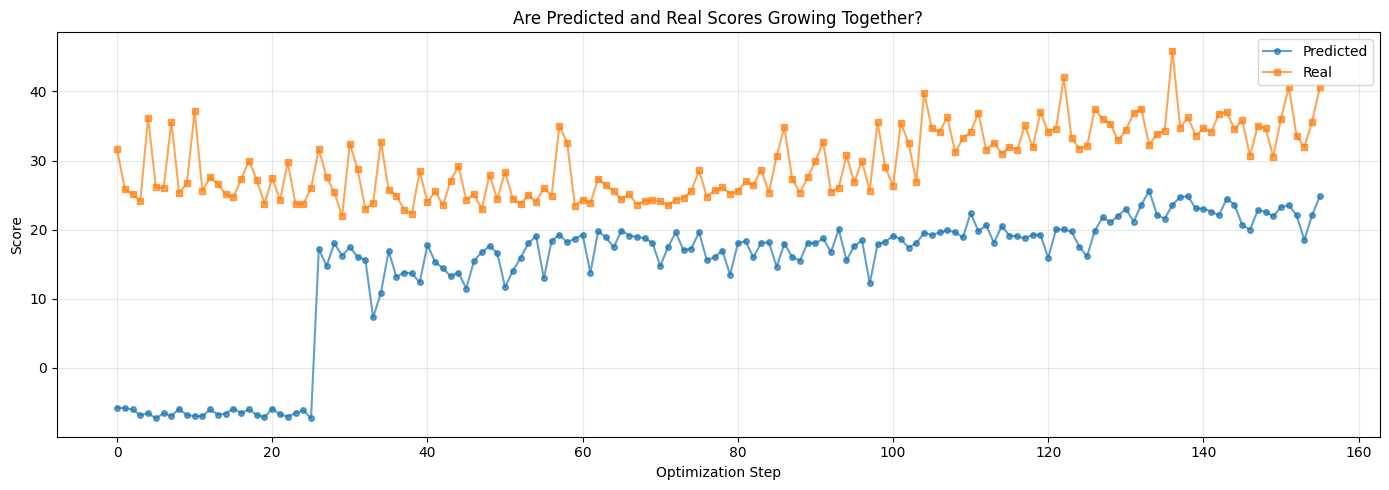

In [9]:
# 3. RL Loop
model = LSTMGoalDirected(vocab_size=20, embedding_dim=16, seq_len=55, hidden_dim=64)
model.load_model('models/lstm_goal_directed_GB1-pretrained.pth')


values = rl_loop(model, rf, oracle, num_iterations=6, batch_size=128, X_train=X_train, y_train=y_train, GB1=True)
values_df = pd.DataFrame(values)
values_df.head()
plot_results(values_df)

/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


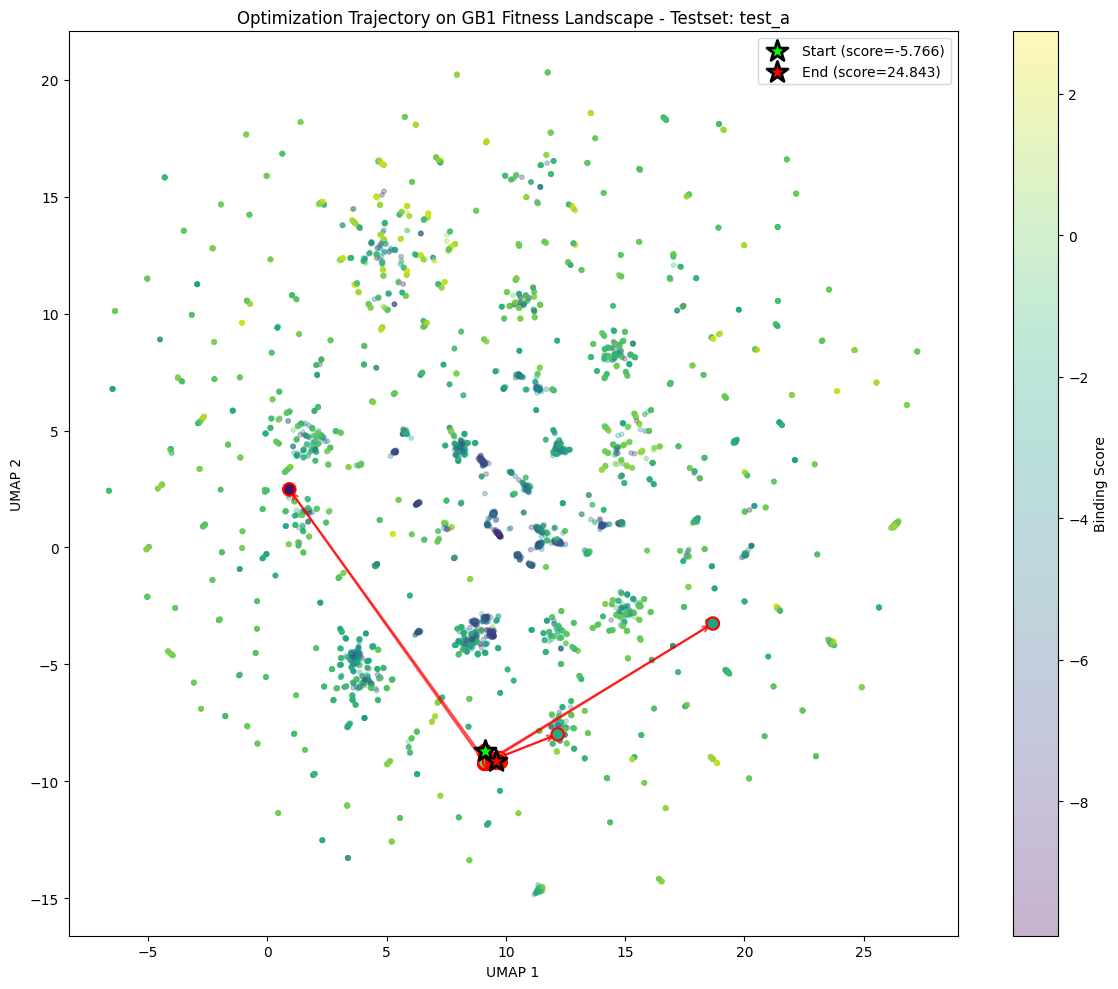

In [14]:
values_df['mutation'] = values_df['mutation'].apply(
    lambda seq: tf.one_hot(list(seq), depth=20).numpy().flatten()
)


plot_umap_embedding(df, 'test_a', values_df)

2026-02-25 15:15:32.325891: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 410643200 exceeds 10% of free system memory.
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


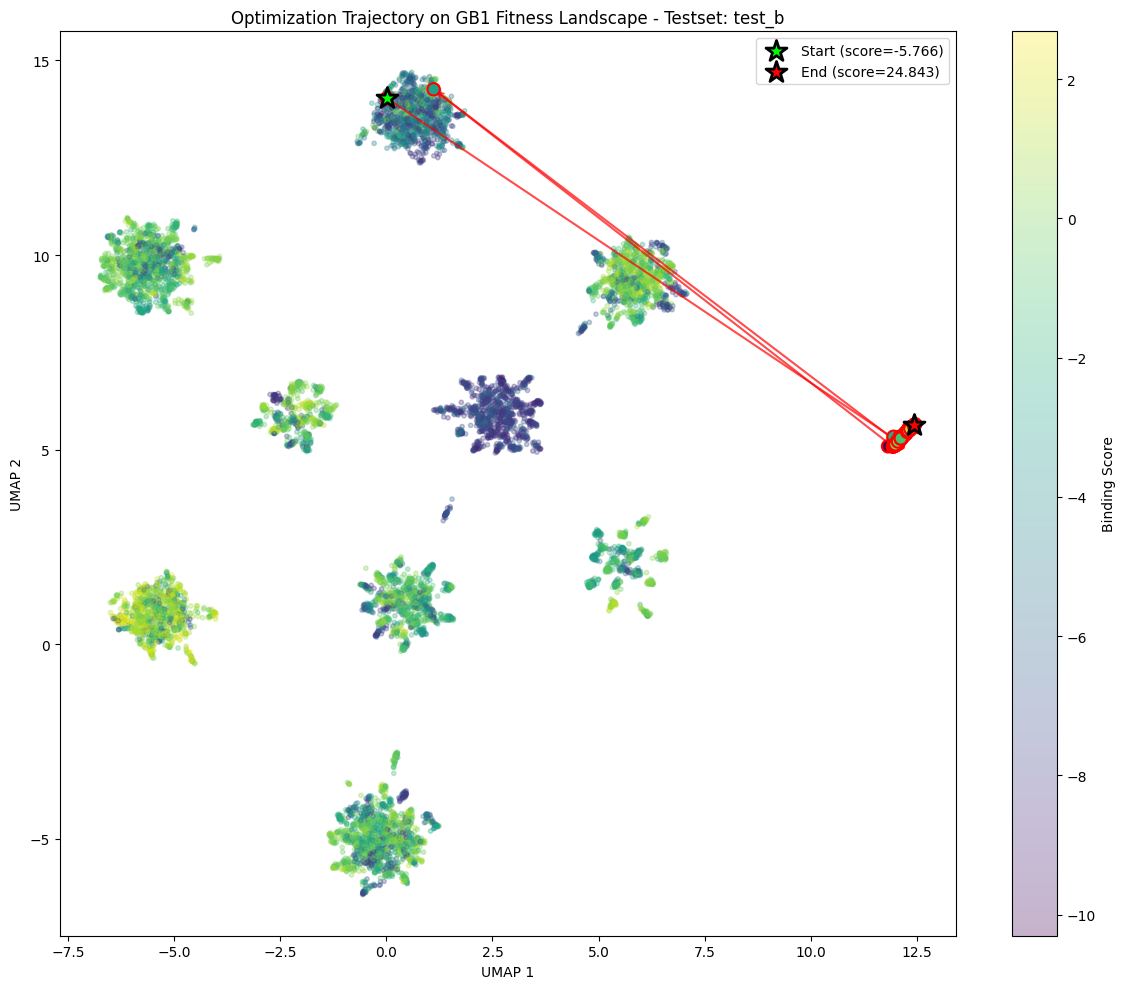

In [15]:
plot_umap_embedding(df, 'test_b', values_df)

2026-02-25 15:15:48.180343: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 175761080 exceeds 10% of free system memory.
2026-02-25 15:15:48.425562: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1757610800 exceeds 10% of free system memory.
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


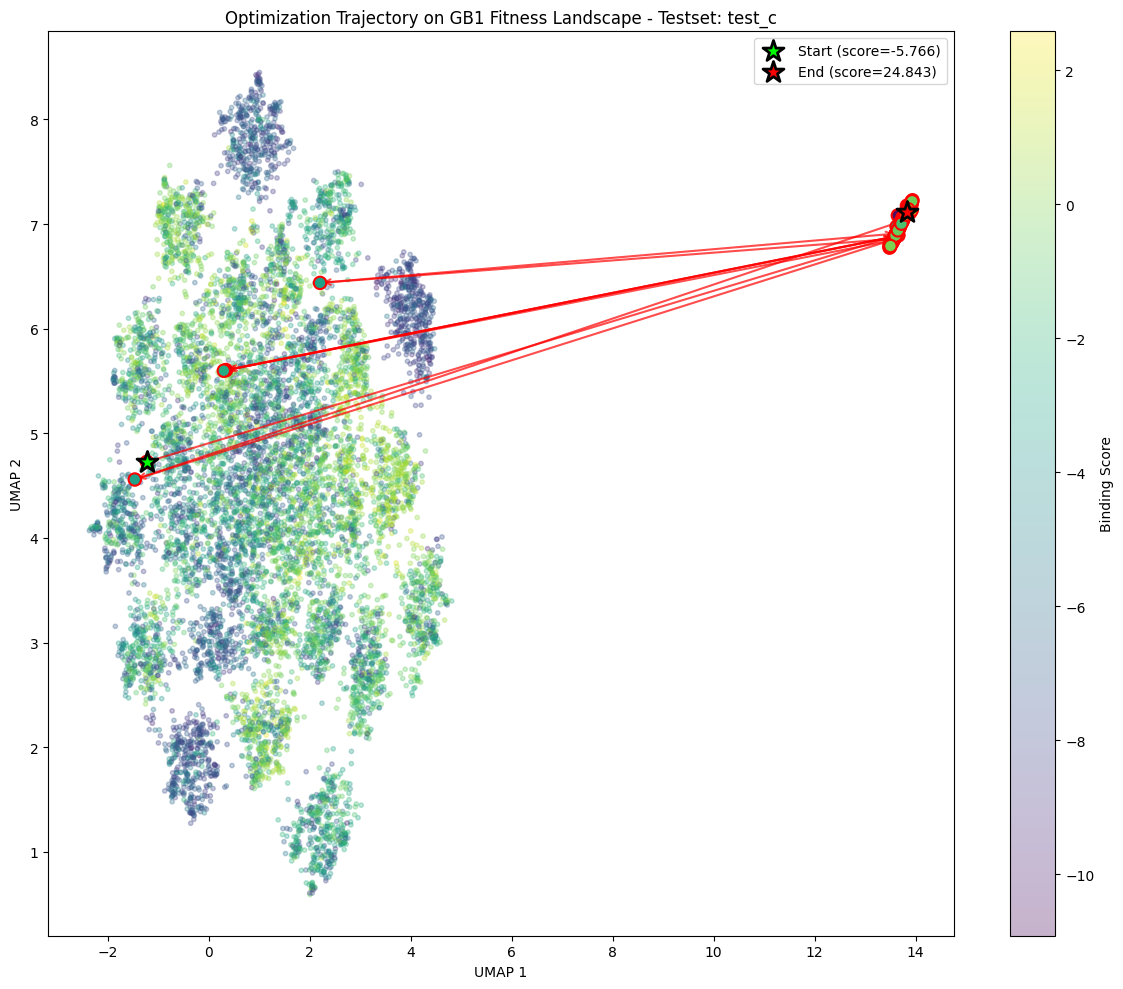

In [16]:
plot_umap_embedding(df, 'test_c', values_df)